# Thompson Sampling


## Importing the libraries

In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Data preprocessing

### Importing the data

In [170]:
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')
dataset.head()

,Ad 1,Ad 2,Ad 3,Ad 4,Ad 5,Ad 6,Ad 7,Ad 8,Ad 9,Ad 10
0,1,0,0,0,1,0,0,0,1,0
1,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0


In [171]:
import random
random.seed(0)
N = 1000
d = 10
ads_selected = []
numbers_of_rewards_0 = [0] * 10
numbers_of_rewards_1 = [0] * 10
total_reward = 0

for n in range(0, N):
  ad = 0
  max_random = 0

  for i in range(0, d):
    teta_i = random.betavariate(numbers_of_rewards_1[i] + 1, numbers_of_rewards_0[i] + 1)

    if (teta_i > max_random):
      max_random = teta_i
      ad = i

  ads_selected.append(ad)
  reward = dataset.values[n, ad]

  if(reward == 1):
    numbers_of_rewards_1[ad] += 1
  else:
    numbers_of_rewards_0[ad] += 1
  total_reward += reward

In [172]:
total_reward

np.int64(223)

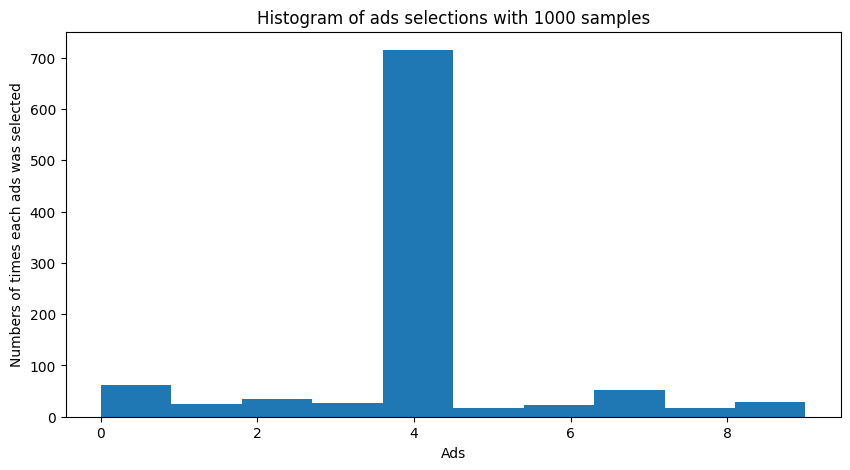

In [173]:
plt.subplots(figsize=(10, 5))
plt.hist(ads_selected)
plt.title(f"Histogram of ads selections with {N} samples")
plt.xlabel("Ads")
plt.ylabel("Numbers of times each ads was selected")
plt.show()